# Rolex Watch Price Analysis - Part 6: K-Means Clustering Analysis
## Market Segmentation Using Unsupervised Learning


## Libraries and settings


In [63]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('default')

print(os.getcwd())

/Users/adisaljusi/repos/data_analytics/final


## 1. Load and Prepare Data


In [64]:
df = pd.read_csv('rolex_data_cleaned.csv', encoding='utf-8')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few records:")
df.head()


Dataset shape: (2373, 19)

First few records:


,web_scraper_order,brand_raw,model_raw,reference_number_raw,movement_type,condition_category,seller_type,case_material_clean,bracelet_material_clean,material_category,country,city,price,year,age,has_box,has_papers,has_complete_set,is_professional
0,1766787541-2,Rolex,Datejust 31,278274,Automatic,New,Professional dealer,Steel,Steel,Steel,Netherlands,Franeker,11415.0,2023.0,1.0,1,1,1,1
1,1766787544-3,Rolex,Cellini Danaos,4233,Manual,Fair,Professional dealer,Rose gold,Unknown,Rose Gold,United States of America,New York City,5248.0,2010.0,14.0,1,1,1,1
2,1766787546-4,Rolex,GMT-Master II,126720VTNR,Automatic,Very Good,Partner Certified Included,Steel,Steel,Steel,Netherlands,Franeker,14745.0,2024.0,0.0,1,1,1,0
3,1766787548-5,Rolex,Sea-Dweller,1665\n \n ...,Automatic,Very Good,Professional dealer,Steel,Steel,Steel,United States of America,Colorado,23009.0,1979.0,45.0,1,1,1,1
4,1766787550-6,Rolex,Explorer,124270\n \n ...,Automatic,Very Good,Partner Certified Included,Steel,Steel,Steel,Netherlands,Franeker,7132.0,2022.0,2.0,1,1,1,0


## 2. Feature Selection for Clustering

For K-means clustering, we'll use:
- **price**: The watch price (key market indicator)
- **age**: How old the watch is
- **is_professional**: Whether sold by professional dealer (binary)
- **condition_encoded**: Numerical encoding of condition (Fair=1, Good=2, Very Good=3, New=4)

Note: We exclude has_box and has_papers as they have zero variance (all watches have both).

In [65]:
# Encode condition as numeric
condition_mapping = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'New': 4}
df['condition_encoded'] = df['condition_category'].map(condition_mapping)

cluster_features = ['price', 'age', 'is_professional', 'condition_encoded']
df_cluster = df[cluster_features].dropna()

print(f"Data for clustering: {df_cluster.shape[0]:,} samples, {df_cluster.shape[1]} features")
print(f"\nFeatures: {cluster_features}")
print(f"\nBasic statistics:")
print(df_cluster.describe())
print(f"\nFeature variance check:")
for col in cluster_features:
    print(f"  {col}: std = {df_cluster[col].std():.4f}")

Data for clustering: 1,145 samples, 4 features

Features: ['price', 'age', 'is_professional', 'condition_encoded']

Basic statistics:
               price          age  is_professional  condition_encoded
count    1145.000000  1145.000000       1145.00000        1145.000000
mean    13543.712664    14.399127          0.60262           3.006987
std     12860.541636    15.672975          0.48957           0.571729
min      1449.000000     0.000000          0.00000           1.000000
25%      6842.000000     2.000000          0.00000           3.000000
50%     10465.000000     8.000000          1.00000           3.000000
75%     15035.000000    23.000000          1.00000           3.000000
max    179824.000000    82.000000          1.00000           4.000000

Feature variance check:
  price: std = 12860.5416
  age: std = 15.6730
  is_professional: std = 0.4896
  condition_encoded: std = 0.5717


## 3. Feature Scaling

K-means clustering is sensitive to the scale of features. We'll use StandardScaler to normalize all features to have mean=0 and std=1.


In [66]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print(f"Scaled data shape: {X_scaled.shape}")
print(f"\nScaled data statistics:")
print(f"  Mean: {X_scaled.mean(axis=0)}")
print(f"  Std: {X_scaled.std(axis=0)}")


Scaled data shape: (1145, 4)

Scaled data statistics:
  Mean: [-6.20561341e-17 -5.58505207e-17  8.68785878e-17 -2.32710503e-16]
  Std: [1. 1. 1. 1.]


## 4. Determine Optimal Number of Clusters

We'll use two methods:
1. **Elbow Method**: Look for the "elbow" in the inertia plot
2. **Silhouette Score**: Measure cluster quality


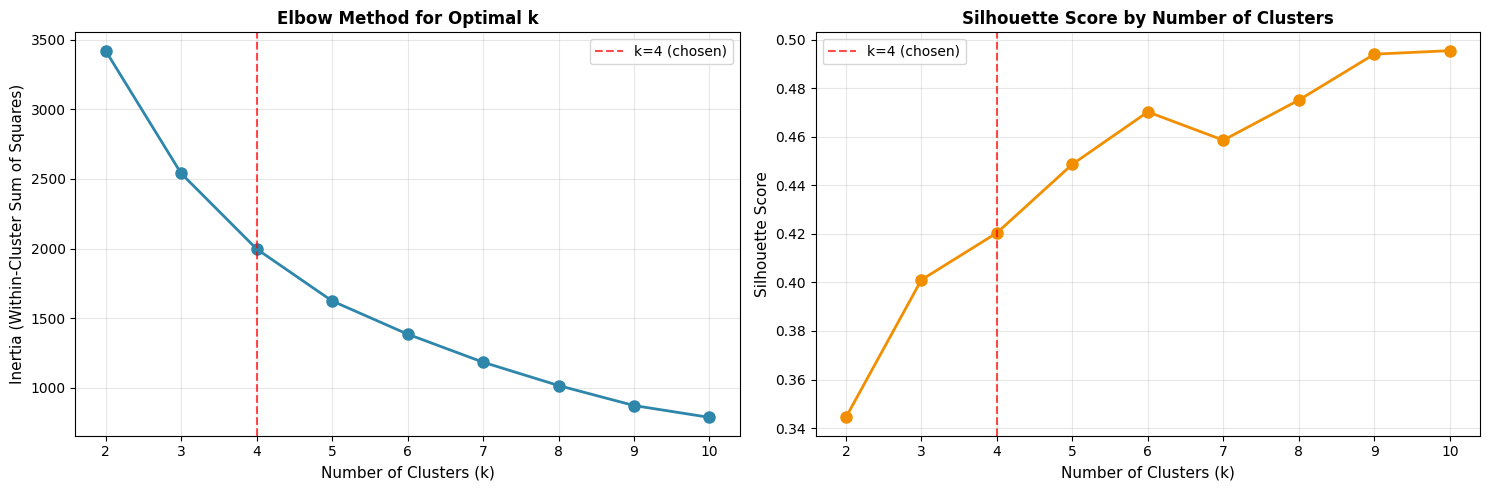

Inertia and Silhouette Scores:
  k=2: Inertia=3,420.93, Silhouette=0.3444
  k=3: Inertia=2,540.20, Silhouette=0.4010
  k=4: Inertia=1,997.52, Silhouette=0.4204
  k=5: Inertia=1,624.24, Silhouette=0.4486
  k=6: Inertia=1,385.78, Silhouette=0.4702
  k=7: Inertia=1,184.27, Silhouette=0.4586
  k=8: Inertia=1,016.71, Silhouette=0.4751
  k=9: Inertia=873.04, Silhouette=0.4940
  k=10: Inertia=787.95, Silhouette=0.4954


In [67]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='#2E86AB')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11)
axes[0].set_title('Elbow Method for Optimal k', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (chosen)')
axes[0].legend()

axes[1].plot(K_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='#F18F01')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score by Number of Clusters', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (chosen)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Inertia and Silhouette Scores:")
for k, inertia, silh in zip(K_range, inertias, silhouette_scores):
    print(f"  k={k}: Inertia={inertia:,.2f}, Silhouette={silh:.4f}")


Based on the elbow plot and silhouette scores, k=4 provides good separation without over-segmenting the market.

## 5. Apply K-Means Clustering with k=4


In [68]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_cluster['cluster'] = clusters

print(f"Cluster distribution:")
print(df_cluster['cluster'].value_counts().sort_index())
print(f"\nSilhouette score: {silhouette_score(X_scaled, clusters):.4f}")


Cluster distribution:
cluster
0    426
1    244
2    403
3     72
Name: count, dtype: int64

Silhouette score: 0.4204


## 6. Cluster Profiling

Analyze the characteristics of each cluster by examining the mean values of each feature.


In [69]:
cluster_profiles = df_cluster.groupby('cluster')[cluster_features].mean().round(2)
cluster_counts = df_cluster.groupby('cluster').size()
cluster_profiles['count'] = cluster_counts

print("Cluster Characteristics (Mean Values):")
print(cluster_profiles)


Cluster Characteristics (Mean Values):
            price    age  is_professional  condition_encoded  count
cluster                                                            
0        10265.52  14.80             0.00               3.06    426
1         8375.36  30.66             0.97               2.38    244
2        13459.24   5.28             1.00               3.35    403
3        50927.44   8.00             0.69               2.90     72


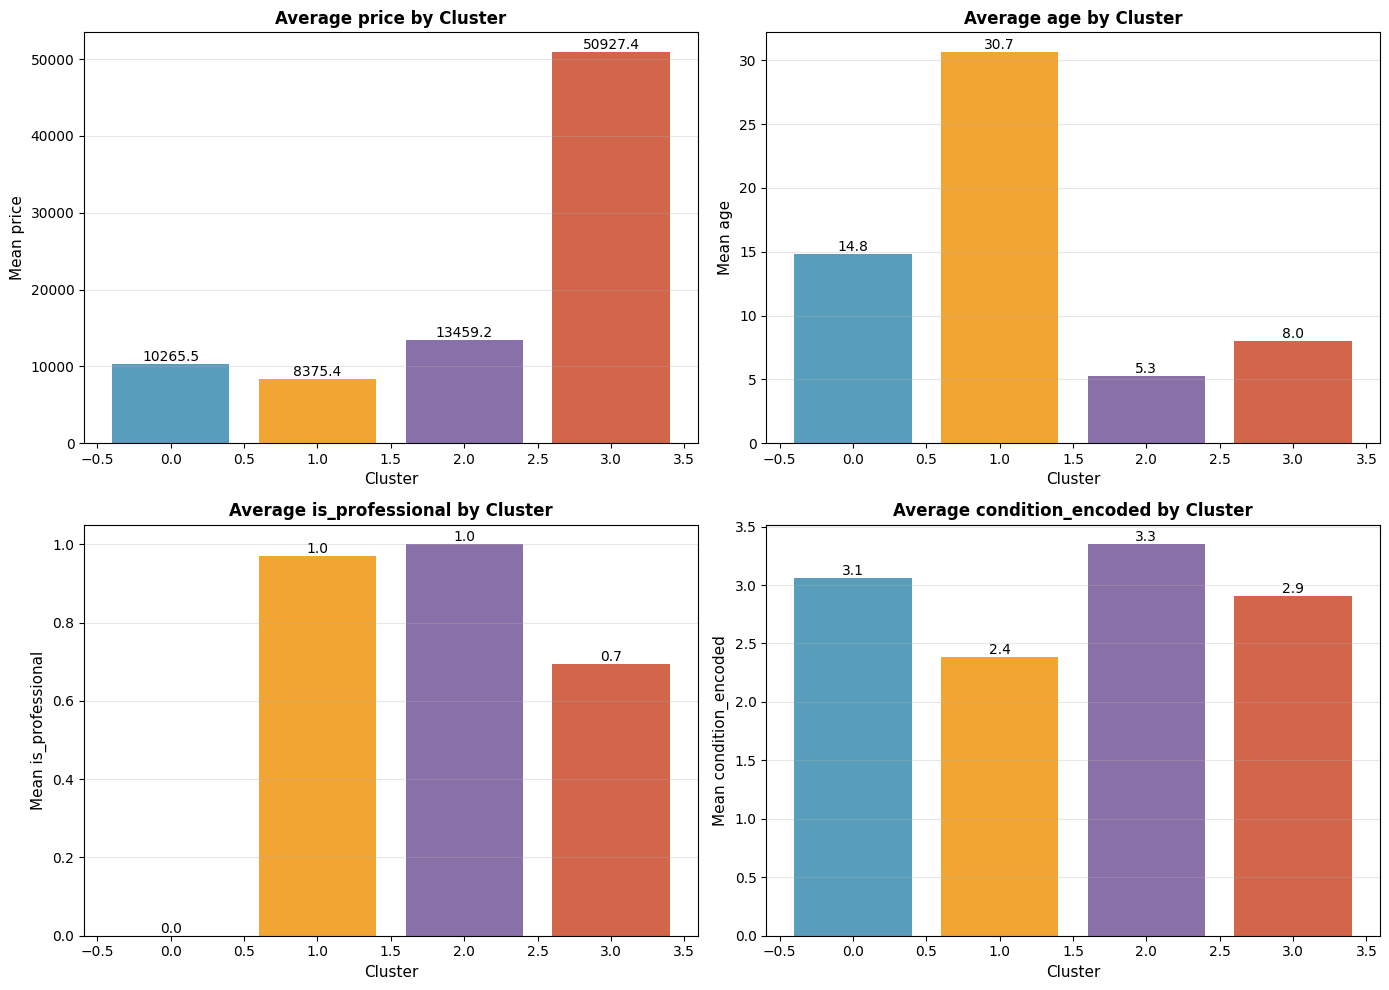

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feature in enumerate(cluster_features):
    ax = axes[idx // 2, idx % 2]
    cluster_means = df_cluster.groupby('cluster')[feature].mean()
    colors = ['#2E86AB', '#F18F01', '#6A4C93', '#C73E1D']
    ax.bar(cluster_means.index, cluster_means.values, color=colors, alpha=0.8)
    ax.set_xlabel('Cluster', fontsize=11)
    ax.set_ylabel(f'Mean {feature}', fontsize=11)
    ax.set_title(f'Average {feature} by Cluster', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    for i, v in enumerate(cluster_means.values):
        ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## 7. Cluster Visualization


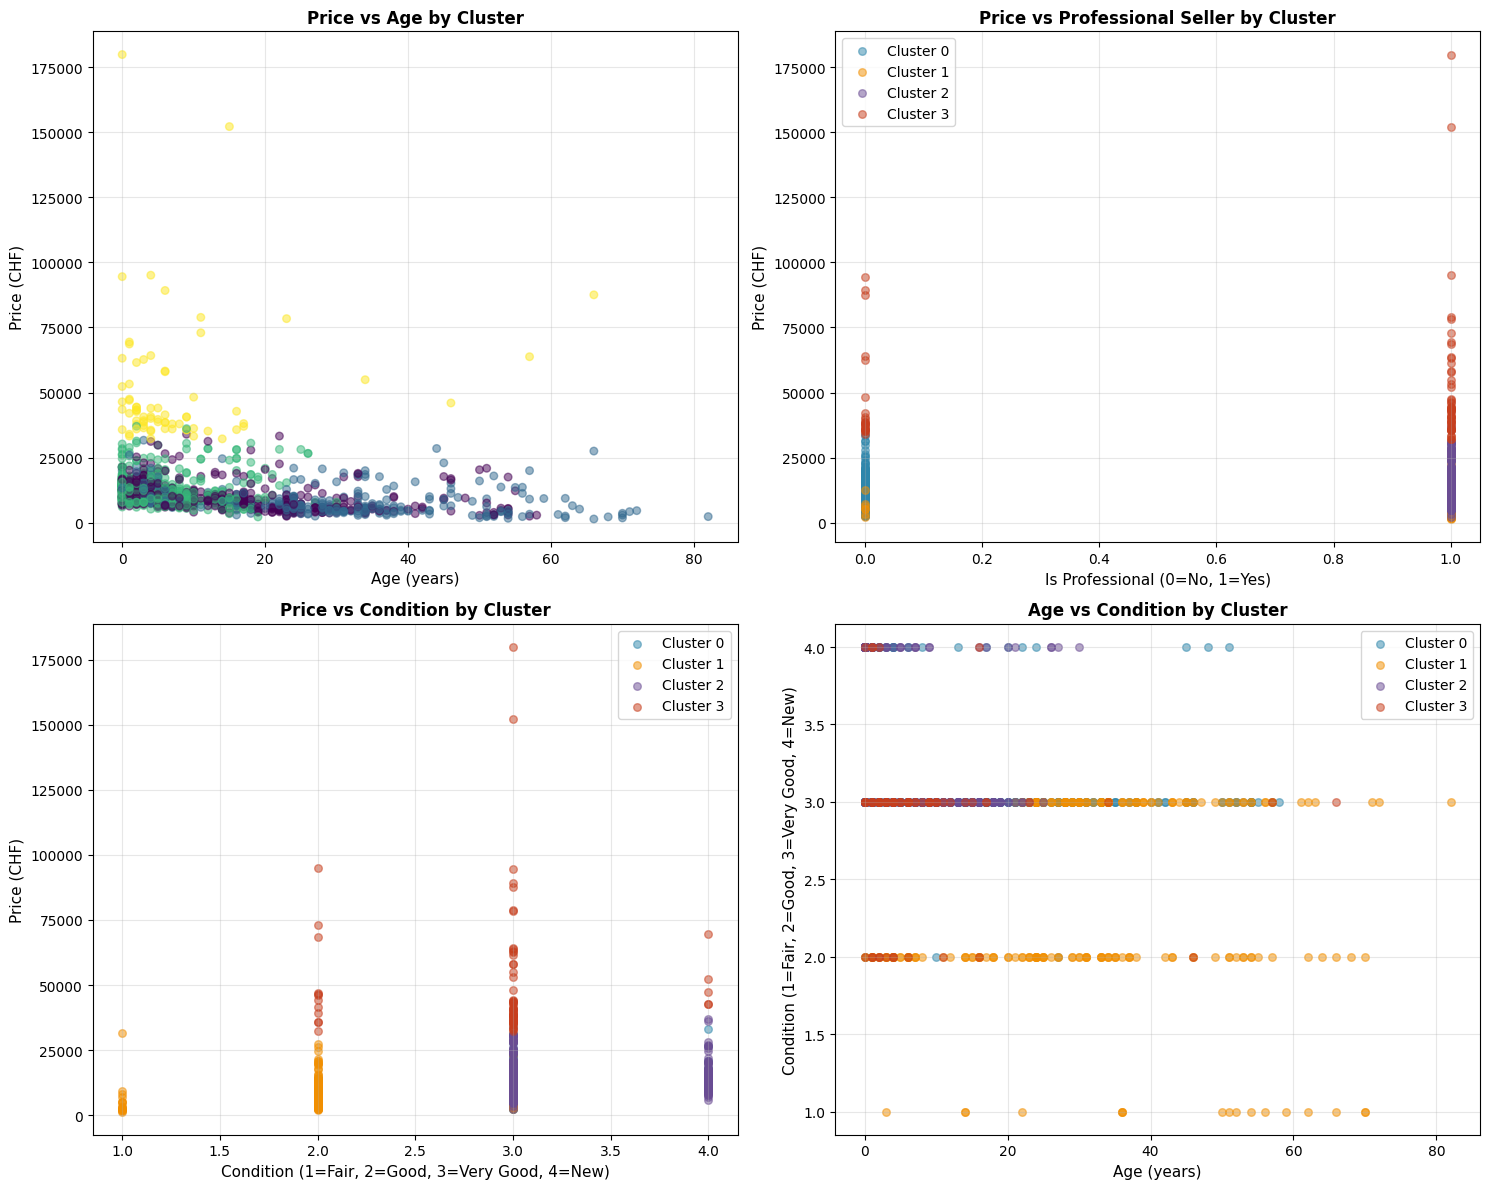

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

colors = ['#2E86AB', '#F18F01', '#6A4C93', '#C73E1D']
cluster_labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

# Price vs Age
axes[0, 0].scatter(df_cluster['age'], df_cluster['price'],
                   c=df_cluster['cluster'], cmap='viridis', alpha=0.5, s=30)
axes[0, 0].set_xlabel('Age (years)', fontsize=11)
axes[0, 0].set_ylabel('Price (CHF)', fontsize=11)
axes[0, 0].set_title('Price vs Age by Cluster', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Price vs Professional Seller
for i in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == i]
    axes[0, 1].scatter(cluster_data['is_professional'], cluster_data['price'],
                       c=colors[i], label=f'Cluster {i}', alpha=0.5, s=30)
axes[0, 1].set_xlabel('Is Professional (0=No, 1=Yes)', fontsize=11)
axes[0, 1].set_ylabel('Price (CHF)', fontsize=11)
axes[0, 1].set_title('Price vs Professional Seller by Cluster', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Price vs Condition
for i in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == i]
    axes[1, 0].scatter(cluster_data['condition_encoded'], cluster_data['price'],
                       c=colors[i], label=f'Cluster {i}', alpha=0.5, s=30)
axes[1, 0].set_xlabel('Condition (1=Fair, 2=Good, 3=Very Good, 4=New)', fontsize=11)
axes[1, 0].set_ylabel('Price (CHF)', fontsize=11)
axes[1, 0].set_title('Price vs Condition by Cluster', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Age vs Condition
for i in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == i]
    axes[1, 1].scatter(cluster_data['age'], cluster_data['condition_encoded'],
                       c=colors[i], label=f'Cluster {i}', alpha=0.5, s=30)
axes[1, 1].set_xlabel('Age (years)', fontsize=11)
axes[1, 1].set_ylabel('Condition (1=Fair, 2=Good, 3=Very Good, 4=New)', fontsize=11)
axes[1, 1].set_title('Age vs Condition by Cluster', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

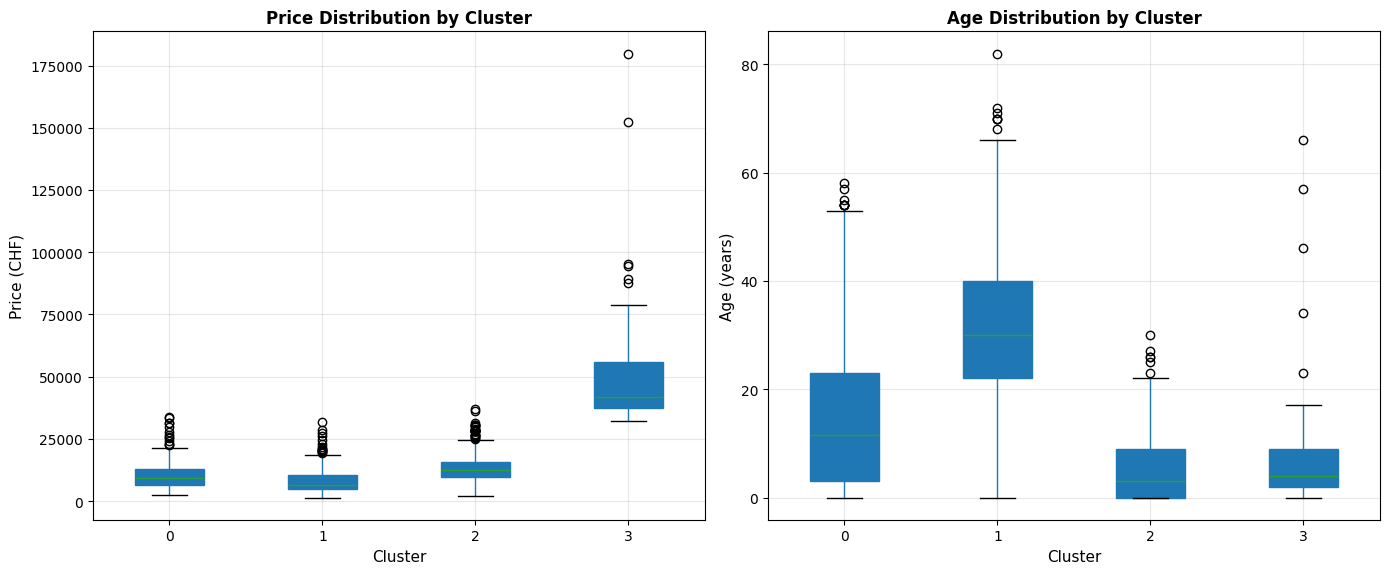

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_cluster.boxplot(column='price', by='cluster', ax=axes[0], patch_artist=True)
axes[0].set_xlabel('Cluster', fontsize=11)
axes[0].set_ylabel('Price (CHF)', fontsize=11)
axes[0].set_title('Price Distribution by Cluster', fontsize=12, fontweight='bold')
plt.suptitle('')
axes[0].grid(alpha=0.3)

df_cluster_with_age = df_cluster[df_cluster['age'].notna()]
df_cluster_with_age.boxplot(column='age', by='cluster', ax=axes[1], patch_artist=True)
axes[1].set_xlabel('Cluster', fontsize=11)
axes[1].set_ylabel('Age (years)', fontsize=11)
axes[1].set_title('Age Distribution by Cluster', fontsize=12, fontweight='bold')
plt.suptitle('')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 7.3 PCA Visualization

Reducing the 4-dimensional feature space to 2D using Principal Component Analysis for visualization:

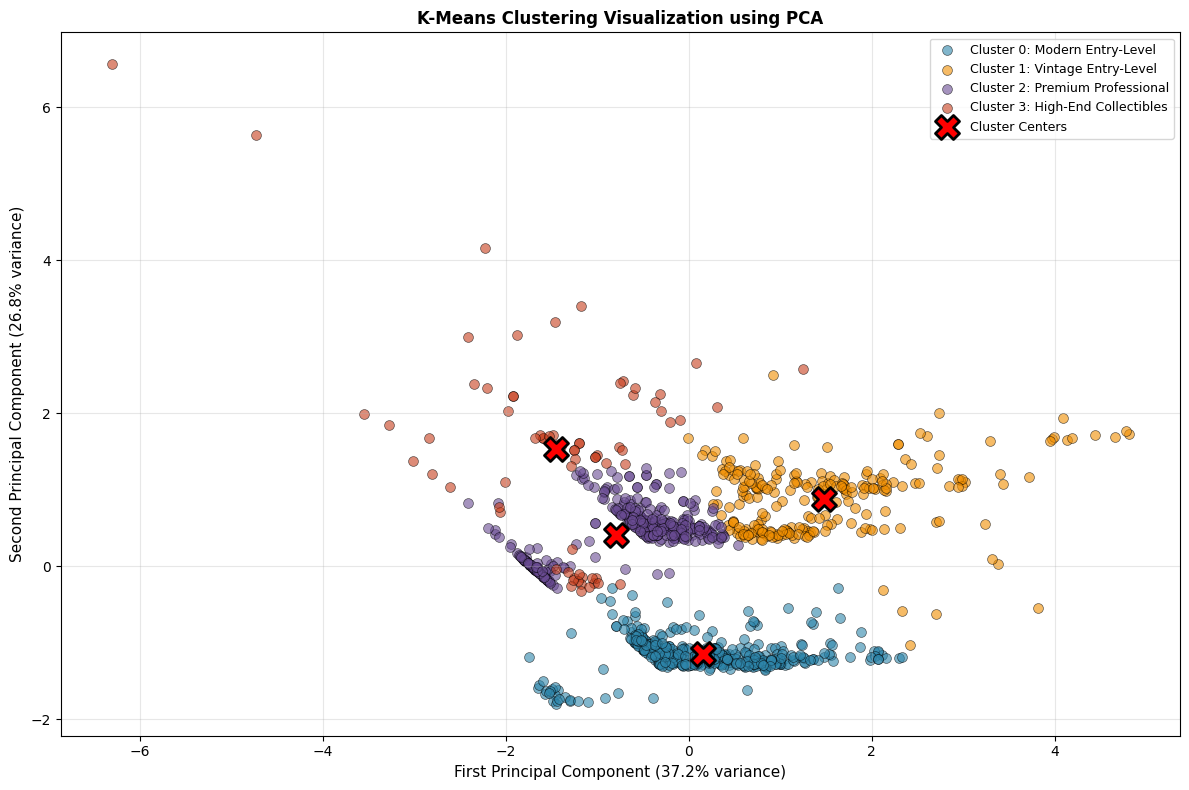

PCA Explained Variance:
  PC1: 37.25%
  PC2: 26.83%
  Total: 64.08% of variance explained by 2 components


In [73]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot each cluster with different colors
colors = ['#2E86AB', '#F18F01', '#6A4C93', '#C73E1D']
cluster_names = ['Cluster 0: Modern Entry-Level', 'Cluster 1: Vintage Entry-Level',
                 'Cluster 2: Premium Professional', 'Cluster 3: High-End Collectibles']

for i in range(4):
    mask = clusters == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=colors[i], label=cluster_names[i], 
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

# Add cluster centers in PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], 
           c='red', marker='X', s=300, edgecolors='black', linewidth=2,
           label='Cluster Centers', zorder=10)

ax.set_xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('K-Means Clustering Visualization using PCA', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"PCA Explained Variance:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.2f}% of variance explained by 2 components")

## 8. Cluster Profiles

Detailed characteristics of each identified segment:

In [74]:
# Add cluster back to original dataframe
df_with_clusters = df.copy()
df_with_clusters['cluster'] = np.nan
df_with_clusters.loc[df_cluster.index, 'cluster'] = clusters

# Detailed cluster analysis
for i in range(4):
    cluster_data = df_with_clusters[df_with_clusters['cluster'] == i]
    
    print(f"\nCluster {i}:")
    print(f"Size: {len(cluster_data):,} watches ({len(cluster_data)/len(df_with_clusters)*100:.1f}% of total)")
    print(f"Average Price: {cluster_data['price'].mean():,.2f} CHF")
    print(f"Median Price: {cluster_data['price'].median():,.2f} CHF")
    print(f"Price Range: {cluster_data['price'].min():,.2f} - {cluster_data['price'].max():,.2f} CHF")
    
    if cluster_data['age'].notna().sum() > 0:
        print(f"Average Age: {cluster_data['age'].mean():.1f} years")
    
    print(f"Professional Seller: {cluster_data['is_professional'].mean()*100:.1f}%")
    
    if cluster_data['condition_category'].notna().sum() > 0:
        print(f"Average Condition: {cluster_data['condition_encoded'].mean():.2f}/4")
        print(f"Most Common Condition: {cluster_data['condition_category'].mode()[0] if len(cluster_data['condition_category'].mode()) > 0 else 'N/A'}")
    
    print(f"Material: {cluster_data['material_category'].mode()[0] if len(cluster_data['material_category'].mode()) > 0 else 'N/A'}")
    print(f"Seller Type: {cluster_data['seller_type'].mode()[0] if len(cluster_data['seller_type'].mode()) > 0 else 'N/A'}")



Cluster 0:
Size: 426 watches (18.0% of total)
Average Price: 10,265.52 CHF
Median Price: 9,331.00 CHF
Price Range: 2,507.00 - 33,997.00 CHF
Average Age: 14.8 years
Professional Seller: 0.0%
Average Condition: 3.06/4
Most Common Condition: Very Good
Material: Steel
Seller Type: Partner Certified Included

Cluster 1:
Size: 244 watches (10.3% of total)
Average Price: 8,375.36 CHF
Median Price: 6,536.50 CHF
Price Range: 1,449.00 - 31,712.00 CHF
Average Age: 30.7 years
Professional Seller: 97.1%
Average Condition: 2.38/4
Most Common Condition: Good
Material: Steel
Seller Type: Professional dealer

Cluster 2:
Size: 403 watches (17.0% of total)
Average Price: 13,459.24 CHF
Median Price: 12,393.00 CHF
Price Range: 2,244.00 - 37,065.00 CHF
Average Age: 5.3 years
Professional Seller: 100.0%
Average Condition: 3.35/4
Most Common Condition: Very Good
Material: Steel
Seller Type: Professional dealer

Cluster 3:
Size: 72 watches (3.0% of total)
Average Price: 50,927.44 CHF
Median Price: 41,766.00 C

## 9. Cluster Interpretation

Assigning segment names based on observed characteristics:

### 9.1 Summary Table

In [75]:
# Create comparison table
comparison_data = []

for i in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == i]
    full_cluster_data = df_with_clusters[df_with_clusters['cluster'] == i]
    
    comparison_data.append({
        'Cluster': i,
        'Segment': segment_names[i],
        'N': len(cluster_data),
        '%': f"{len(cluster_data)/len(df_cluster)*100:.1f}%",
        'Avg Price': f"{cluster_data['price'].mean():,.0f}",
        'Price Range': f"{cluster_data['price'].min():,.0f}-{cluster_data['price'].max():,.0f}",
        'Avg Age': f"{cluster_data['age'].mean():.1f}",
        'Pro %': f"{cluster_data['is_professional'].mean()*100:.0f}%",
        'Condition': f"{cluster_data['condition_encoded'].mean():.2f}",
        'Material': full_cluster_data['material_category'].mode()[0] if len(full_cluster_data['material_category'].mode()) > 0 else 'N/A'
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


 Cluster                     Segment   N     % Avg Price    Price Range Avg Age Pro % Condition    Material
       0          Modern Entry-Level 426 37.2%    10,266   2,507-33,997    14.8    0%      3.06       Steel
       1         Vintage Entry-Level 244 21.3%     8,375   1,449-31,712    30.7   97%      2.38       Steel
       2 Premium Professional Market 403 35.2%    13,459   2,244-37,065     5.3  100%      3.35       Steel
       3       High-End Collectibles  72  6.3%    50,927 32,243-179,824     8.0   69%      2.90 Yellow Gold


In [76]:
# Determine segment names based on characteristics
segment_names = {}
segment_descriptions = {}

for i in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == i]
    avg_price = cluster_data['price'].mean()
    avg_age = cluster_data['age'].mean()
    avg_condition = cluster_data['condition_encoded'].mean()
    pct_professional = cluster_data['is_professional'].mean()
    
    # Classify based on price and other characteristics
    if avg_price > df_cluster['price'].quantile(0.75):
        if avg_condition > 3.0:
            segment_names[i] = "Ultra-Luxury Premium"
            segment_descriptions[i] = "High-value watches in excellent condition"
        else:
            segment_names[i] = "High-End Collectibles"
            segment_descriptions[i] = "Expensive watches, varying condition"
    elif avg_price > df_cluster['price'].median():
        if pct_professional > 0.7:
            segment_names[i] = "Premium Professional Market"
            segment_descriptions[i] = "Mid-to-high price, mostly professional dealers"
        else:
            segment_names[i] = "Premium Private Market"
            segment_descriptions[i] = "Mid-to-high price, more private sellers"
    else:
        if avg_age > 25:
            segment_names[i] = "Vintage Entry-Level"
            segment_descriptions[i] = "Older watches at accessible prices"
        else:
            segment_names[i] = "Modern Entry-Level"
            segment_descriptions[i] = "Newer watches at entry-level pricing"

print("\nSegment Summary:")
for i in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == i]
    print(f"Cluster {i}: {segment_names[i]}")
    print(f"  N={len(cluster_data):,} | Price={cluster_data['price'].mean():,.0f} CHF | Age={cluster_data['age'].mean():.1f}yr | Pro={cluster_data['is_professional'].mean()*100:.0f}% | Cond={cluster_data['condition_encoded'].mean():.2f}/4")



Segment Summary:
Cluster 0: Modern Entry-Level
  N=426 | Price=10,266 CHF | Age=14.8yr | Pro=0% | Cond=3.06/4
Cluster 1: Vintage Entry-Level
  N=244 | Price=8,375 CHF | Age=30.7yr | Pro=97% | Cond=2.38/4
Cluster 2: Premium Professional Market
  N=403 | Price=13,459 CHF | Age=5.3yr | Pro=100% | Cond=3.35/4
Cluster 3: High-End Collectibles
  N=72 | Price=50,927 CHF | Age=8.0yr | Pro=69% | Cond=2.90/4


### 9.2 Segment Characteristics
Segment characteristics and market positioning

**Cluster 0: Modern Entry-Level (Private Market)**

This segment consists entirely of private sellers through certified
partners. Average price around 10K CHF for watches averaging 15 years old.
Condition is good (3.06/4) despite the age. Represents about 37% of the
market with complete documentation. Steel is dominant material.
Note: Price-to-condition ratio is favorable compared to dealer prices.

**Cluster 1: Vintage Entry-Level**

Older watches (30+ years) at the lowest price point (~8.4K CHF). Nearly
all from professional dealers (97%). Lower condition scores (2.38/4)
reflect their age. This is the vintage market segment - collectors
seeking authentic old pieces rather than pristine condition. Smallest
segment at 21% of market.

**Cluster 2: Premium Professional Market**

Exclusively professional dealers. Newer watches (avg 5.3 years) in
excellent condition (3.35/4). Price premium over entry-level (~13.5K)
is justified by condition and dealer guarantees. Largest professional
segment at 35% of market. Steel watches dominate but condition is key
differentiator from Cluster 0.

**Cluster 3: High-End Collectibles**

Small luxury segment (6% of market) with average price over 50K CHF.
Yellow gold is the dominant material - price driven by precious metal
content more than condition (2.90/4). Mix of professional and private
sellers. This is the investment/precious metal segment rather than
purely the watch functionality market.

Key Insight: Market segments align with buyer motivations:

**Clusters 0 & 2:** Modern watch buyers (differ by seller type/condition)

**Cluster 1:** Vintage collectors prioritizing age over condition

**Cluster 3:** Precious metal investors/luxury buyers


## 10. Discussion

The clustering analysis reveals four distinct market segments based on price, age, condition, and seller type. The separation between segments is driven primarily by price and seller professionalism, with age and condition as secondary factors.

**Market Structure:**
The vintage market (Cluster 1) is clearly separated from modern markets by age (30+ vs <15 years). Among modern watches, professional dealers command a premium (~31% higher) for better condition pieces (Cluster 2 vs Cluster 0), while private certified sellers offer better value. The luxury segment (Cluster 3) is materially different - precious metals drive pricing rather than watch condition or age.

**Seller Dynamics:**
Professional dealer presence varies significantly across segments: 0% in Cluster 0 (private certified sellers), 97% in vintage, and 100% in premium modern. This suggests certification programs successfully enable private sellers to compete in the modern mid-range market. However, vintage and premium segments remain dealer-dominated, likely due to authentication complexity and buyer risk aversion.

**Pricing Observations:**
Steel watches appear in Clusters 0-2 with prices ranging from 8K to 13.5K CHF depending on age, condition, and seller type. Cluster 3's yellow gold dominance shows precious metal content creates a distinct pricing tier (50K+ avg) independent of typical condition metrics. This suggests two separate buyer groups: watch collectors (Clusters 0-2) and precious metal investors (Cluster 3).

**Limitations:**
All clustered watches have complete documentation (box + papers), limiting analysis to this subset. Missing the no-documentation market segment may bias understanding of value drivers. Additionally, the silhouette score of 0.42 indicates moderate cluster separation - some overlap exists between adjacent price tiers.

## Jupyter notebook --footer info-- 


In [78]:
import os
import platform
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')


-----------------------------------
POSIX
Darwin | 25.2.0
Datetime: 2025-12-29 15:05:38
Python Version: 3.11.13
-----------------------------------
